In [ ]:
import kagglehub
import os # Import os module

# Download latest version
path = kagglehub.dataset_download("nirmalsankalana/plantdoc-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'plantdoc-dataset' dataset.
Path to dataset files: /kaggle/input/plantdoc-dataset
Contents of base_path (/kaggle/input):
['plantdoc-dataset']
Contents of path (/kaggle/input/plantdoc-dataset):
['folder_renamer.py', 'file_renamer.py', 'test', 'train']


In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

# Check for GPU availability with TensorFlow
print("TensorFlow GPU Check:")
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU available: {gpu_devices}")
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU devices found. Using CPU.")

# Check for CUDA availability with PyTorch (optional, but good practice)
try:
    import torch
    print("\nPyTorch GPU Check:")
    if torch.cuda.is_available():
        print(f"CUDA available: {torch.cuda.is_available()}")
        print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    else:
        print("CUDA not available for PyTorch.")
except ImportError:
    print("\nPyTorch not installed. Skipping PyTorch GPU check.")

TensorFlow GPU Check:
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

PyTorch GPU Check:
CUDA available: True
CUDA device name: Tesla T4


### Load and Preprocess the Dataset

Now we will load the image dataset using `image_dataset_from_directory`. We'll assume the dataset downloaded by KaggleHub (`path`) contains 'train', 'test', and 'valid' (or 'val') subdirectories. We will also define image size and batch size, and apply basic preprocessing like resizing and normalization.

In [ ]:
IMAGE_SIZE = (128, 128) # Smaller size for faster training, adjust if needed
BATCH_SIZE = 32

train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

print(f"Looking for train data in: {train_dir}")
print(f"Looking for test data in: {test_dir}")

# Define a split ratio for validation
VALIDATION_SPLIT = 0.2 # 20% of training data for validation
SEED = 42 # For reproducibility

# Load training dataset and split it for validation
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=IMAGE_SIZE,
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, # Use the same train_dir for validation subset
    labels='inferred',
    label_mode='int',
    image_size=IMAGE_SIZE,
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True, # Shuffle for validation as well
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=IMAGE_SIZE,
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False # Typically no shuffle for test set
)

# Get class names and number of classes
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nDetected {num_classes} classes: {class_names}")

# Preprocessing: Rescaling pixel values to [0, 1]
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0 # Cast to float32 BEFORE division
    return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_ds = validation_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Looking for train data in: /kaggle/input/plantdoc-dataset/train
Looking for test data in: /kaggle/input/plantdoc-dataset/test
Found 2670 files belonging to 28 classes.
Using 2136 files for training.
Found 2670 files belonging to 28 classes.
Using 534 files for validation.
Found 252 files belonging to 27 classes.

Detected 28 classes: ['Apple_Scab_Leaf', 'Apple_leaf', 'Apple_rust_leaf', 'Bell_pepper_leaf', 'Bell_pepper_leaf_spot', 'Blueberry_leaf', 'Cherry_leaf', 'Corn_Gray_leaf_spot', 'Corn_leaf_blight', 'Corn_rust_leaf', 'Peach_leaf', 'Potato_leaf_early_blight', 'Potato_leaf_late_blight', 'Raspberry_leaf', 'Soyabean_leaf', 'Squash_Powdery_mildew_leaf', 'Strawberry_leaf', 'Tomato_Early_blight_leaf', 'Tomato_Septoria_leaf_spot', 'Tomato_leaf', 'Tomato_leaf_bacterial_spot', 'Tomato_leaf_late_blight', 'Tomato_leaf_mosaic_virus', 'Tomato_leaf_yellow_virus', 'Tomato_mold_leaf', 'Tomato_two_spotted_spider_mites_leaf', 'grape_leaf', 'grape_leaf_black_rot']


### Build the VGG Model

We will use a pre-trained VGG16 model as a base and add custom classification layers on top. This is a common practice for transfer learning in image classification.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load VGG16 base model (excluding the top classification layer)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
)

# Freeze the layers of the base model so they are not updated during training
base_model.trainable = False

# Create a new model on top of the base model
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) # Add dropout for regularization
output_layer = Dense(num_classes, activation='softmax')(x) # Output layer with num_classes neurons

model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy', # Use 'sparse_categorical_crossentropy' for integer labels
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │         7,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,819,292 (64.16 MB)

 Trainable params: 2,104,604 (8.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Train the Model

Now, let's train our VGG-based model using the preprocessed training and validation datasets. We will train for a few epochs and store the training history.

In [ ]:
EPOCHS = 10 # You can adjust the number of epochs

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=validation_ds
)

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 50s 587ms/step - accuracy: 0.1184 - loss: 3.2262 - val_accuracy: 0.2247 - val_loss: 2.9108
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.2313 - loss: 2.8212 - val_accuracy: 0.2697 - val_loss: 2.7066
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.2884 - loss: 2.5739 - val_accuracy: 0.3127 - val_loss: 2.5410
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.3455 - loss: 2.3328 - val_accuracy: 0.3371 - val_loss: 2.4250
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.3872 - loss: 2.1766 - val_accuracy: 0.3558 - val_loss: 2.3397
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.4321 - loss: 2.0114 - val_accuracy: 0.3745 - val_loss: 2.2792
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.4733 - loss: 1.8672 - val_accuracy: 0.3727 - val_loss: 2.2242
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.5108 - loss: 1.7325 - val_accuracy: 0.3745 -

### Summarize Training Results

After training, we can evaluate the model's performance on the test set and print the final training and validation accuracy and loss.

In [ ]:
# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Print final training and validation metrics
print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.2817 - loss: 2.5814

Test Loss: 2.5814
Test Accuracy: 0.2817

Final Training Accuracy: 0.5843
Final Training Loss: 1.5068
Final Validation Accuracy: 0.3801
Final Validation Loss: 2.1266


### Display Training Plots

Visualizing the training history (accuracy and loss over epochs) helps to understand the model's learning process and identify issues like overfitting or underfitting.

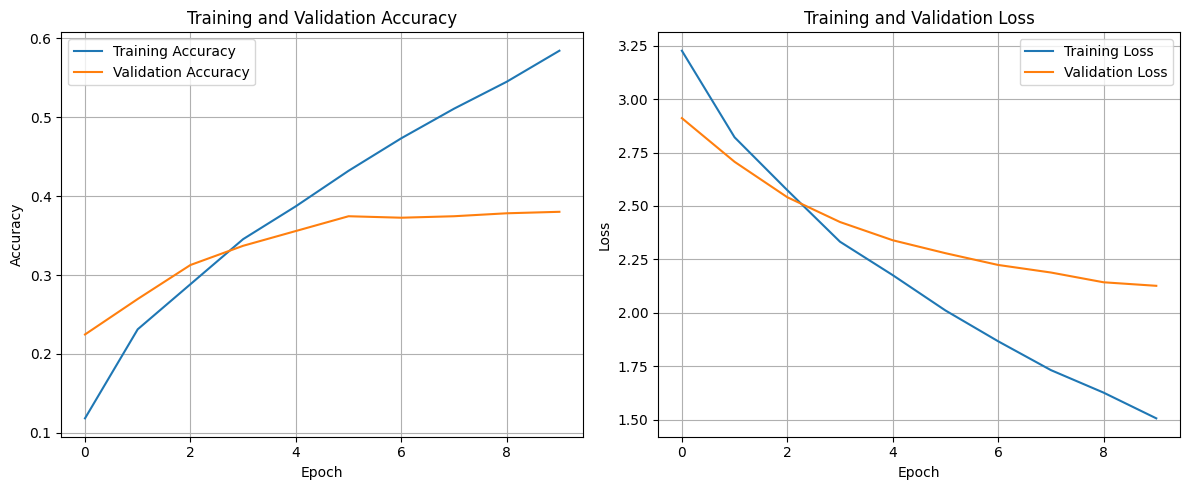

In [ ]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()